<a href="https://colab.research.google.com/github/JessicaSTMatos/Datathon---Fase-5---FIAP/blob/main/Fase_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fase 5 - Datathon**

Nesse Datathon recebemos o desafio de construir um modelo de
Deep Learning, Machine Learning, IA ou outro modelo **capaz de classificar automaticamente o sentimento das
reclamações de clientes** (positivas ou negativas) com base no texto enviado,
e realizar uma análise das principais dores relatadas em cada categoria de
produto financeiro.

Recebemos um conjunto de dados com reclamações de
consumidores sobre produtos e serviços financeiros, contendo o texto da
reclamação, a empresa envolvida e a categoria do produto/serviço (como cartão
de crédito, hipoteca, empréstimo, etc.).

Essas reclamações foram encaminhadas
às empresas e publicadas após confirmação de relacionamento comercial.

O nosso desafio é entender melhor como os consumidores se
sentem em relação a esses serviços e quais problemas são mais recorrentes.

## 1. Preparação dos Dados

1.1 - Instalação e importação das bibliotecas necessárias

In [43]:
!pip install torch torchvision torchaudio transformers scikit-learn pandas

In [44]:
import pandas as pd
import torch
import re
import string
import nltk
import spacy
import unicodedata
import torch.nn as nn
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm import tqdm
from nltk.corpus import stopwords
from torch.utils.data import DataLoader, TensorDataset
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.stem import WordNetLemmatizer
from sklearn.utils import shuffle
import numpy as np

Devido ao tamanho da base original e, conforme orientado em aula, utilizamos a base disponibilizda no Kaggle (https://www.kaggle.com/datasets/shashwatwork/consume-complaints-dataset-fo-nlp?resource=download).

 Utilizamos a biblioteca **kagglehub** para baixar o conjunto de dados diretamente do Kaggle. Primeiro, importamos a biblioteca **kagglehub**.

 Em seguida, a função kagglehub.dataset_download() é chamada com o identificador do dataset ('shashwatwork/consume-complaints-dataset-fo-nlp') para fazer o download.

 O caminho local onde os arquivos do dataset são salvos é armazenado na variável path.

 Finalmente, o print() exibe esse caminho, informando onde podemos encontrar os arquivos baixados.

In [91]:
import kagglehub


path = kagglehub.dataset_download("shashwatwork/consume-complaints-dataset-fo-nlp")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'consume-complaints-dataset-fo-nlp' dataset.
Path to dataset files: /kaggle/input/consume-complaints-dataset-fo-nlp


Após o dataset ter sido baixado e seu caminho estar armazenado na variável path, o próximo passo foi listar o conteúdo do diretório para identificar o arquivo CSV e carregar o arquivo CSV específico a partir desse caminho para um DataFrame do pandas.

In [92]:
import os

files_in_path = os.listdir(path)
print(f"Files in the directory {path}: {files_in_path}")

Files in the directory /kaggle/input/consume-complaints-dataset-fo-nlp: ['complaints_processed.csv']


In [93]:
csv_file_name = 'complaints_processed.csv'
full_path = os.path.join(path, csv_file_name)
df = pd.read_csv(full_path, index_col=0)

print("O arquivo CSV foi carregado com sucesso em um DataFrame.")
print("Exibindo as 5 primeiras linhas do DataFrame:")
df.head()

O arquivo CSV foi carregado com sucesso em um DataFrame.
Exibindo as 5 primeiras linhas do DataFrame:


,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


## Explicação do Embaralhamento da Base de Dados

O embaralhamento da base de dados (`df = shuffle(df)`) foi realizado como uma prática fundamental no pré-processamento de dados para aprendizado de máquina e _Deep Learning_.

### Por que embaralhamos os dados?

1.  **Evitar vieses na divisão entre treino e teste**: Se o dataset original tiver alguma ordem (por exemplo, todas as reclamações positivas primeiro, depois as negativas, ou dados agrupados por data/produto), uma divisão sequencial (e.g., os primeiros 70% para treino e os últimos 30% para teste) resultaria em conjuntos de dados desequilibrados. O embaralhamento garante que os conjuntos de treino e teste sejam representativos do dataset completo.
2.  **Melhorar o treinamento do modelo**: Em algoritmos de _Deep Learning_, como as LSTMs utilizadas neste projeto, os modelos aprendem em _batches_ (pequenos grupos de dados). Se os _batches_ contiverem apenas um tipo de exemplo (e.g., só reclamações negativas), o modelo pode ficar "viciado" nesse padrão e ter dificuldades para generalizar. O embaralhamento assegura que cada _batch_ tenha uma variedade de exemplos, o que leva a um aprendizado mais robusto e eficaz.
3.  **Reduzir a sensibilidade à ordem**: Alguns algoritmos podem ser sensíveis à ordem dos dados. Embaralhar ajuda a mitigar qualquer impacto adverso que uma ordenação específica possa ter sobre o processo de treinamento e a performance final do modelo.

Ao embaralhar o `DataFrame` e resetar seu índice (`df.reset_index(drop=True, inplace=True)`), garantimos que os dados estão dispostos de forma aleatória, preparando-os adequadamente para as etapas subsequentes de divisão e treinamento do modelo.

In [94]:
df = shuffle(df)
df.reset_index(drop=True, inplace=True)
df.head()

,product,narrative
0,credit_reporting,bureau falsely reporting alleged debt fdcpa se...
1,credit_reporting,received document company dated paid full titl...
2,debt_collection,belief credit reporting system important eleme...
3,credit_reporting,submitted written online dispute eqifax remove...
4,credit_reporting,please explain credit card acquired account in...


## 2. Análise Exploratória de Dados (AED)

Optamos por realizar uma análise exploratória inicial dos dados para compreender a estrutura do conjunto de dados, os tipos de dados e identificar possíveis problemas, como valores ausentes, por exemplo.

Para iniciar a Análise Exploratória de Dados verificamos o tamanho da base de dados, a quantidade de categorias de produtos, os tipos de produtos, as estatísticas descritivas, as informações do DataFrame, o número de valores únicos por coluna e os valores ausentes por coluna.

In [95]:
print("Tamanho da base de dados:")
df.shape


Tamanho da base de dados:


(162421, 2)

In [96]:
print("Quantidade de categorias de produtos:")
df['product'].nunique()

Quantidade de categorias de produtos:


5

In [97]:
set(df['product'])

{'credit_card',
 'credit_reporting',
 'debt_collection',
 'mortgages_and_loans',
 'retail_banking'}

In [52]:
print("\nEstatísticas Descritivas:")
df.describe()



Estatísticas Descritivas:


,product,narrative
count,162421,162411
unique,5,124472
top,credit_reporting,victim identity notified collection creditor s...
freq,91179,739


In [98]:
print("Informações do DataFrame:")
df.info()

print("\nNúmero de valores únicos por coluna:")
print(df.nunique())

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   product    162421 non-null  object
 1   narrative  162411 non-null  object
dtypes: object(2)
memory usage: 2.5+ MB

Número de valores únicos por coluna:
product           5
narrative    124472
dtype: int64

Valores ausentes por coluna:
product       0
narrative    10
dtype: int64


Para tratar os valores ausentes identificados na coluna 'narrative' removemos as linhas correspondentes do DataFrame usando o método dropna() e, em seguida, verificamos a operação novamente para ter certeza que não há mais a presença de valores ausentes.

In [99]:
print("Formato do DataFrame antes da remoção de valores nulos:", df.shape)
df.dropna(subset=['narrative'], inplace=True)
print("Formato do DataFrame após da remoção de valores nulos::", df.shape)

print("\nValores ausentes por coluna após a remoção de linhas:")
print(df.isnull().sum())

Formato do DataFrame antes da remoção de valores nulos: (162421, 2)
Formato do DataFrame após da remoção de valores nulos:: (162411, 2)

Valores ausentes por coluna após a remoção de linhas:
product      0
narrative    0
dtype: int64


Optamos por criar um gráfico de barras que mostra a contagem de cada categoria de produto no DataFrame utilizando as bibliotecas matplotlib.pyplot e seaborn para a visualização.

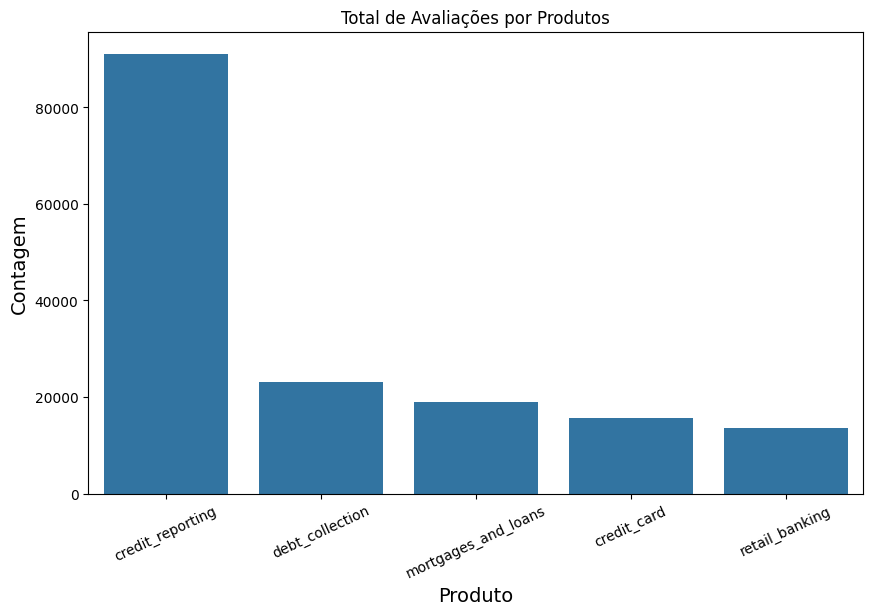

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='product', order=df['product'].value_counts().index)
plt.title('Total de Avaliações por Produtos')
plt.xlabel('Produto', size=14)
plt.xticks(rotation=25)
plt.ylabel('Contagem', size=14)
plt.show()

<Axes: xlabel='num_palavras', ylabel='Count'>

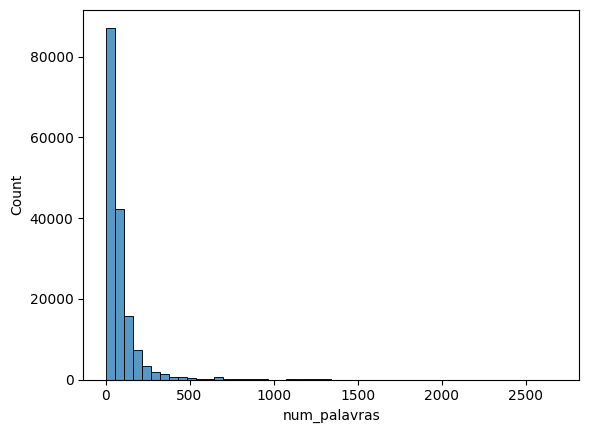

In [105]:
df['num_palavras'] = df['narrative'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
sns.histplot(df['num_palavras'], bins=50)

In [106]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['narrative'])

frequencia = X.sum(axis=0)
palavras = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({'palavra': palavras, 'freq': frequencia.tolist()[0]})
freq_df.sort_values(by='freq', ascending=False).head(20)

,palavra,freq
9528,credit,317561
366,account,316151
33352,report,177193
20621,information,143538
28644,payment,127704
33378,reporting,94522
40173,time,82905
7881,company,79449
10157,day,77044
23437,loan,75353


## 3. Pré-processamento do texto


Para que um modelo estatístico ou de Deep Learning performe bem nessa base de reclamações financeiras, o pré-processamento deve focar em reduzir o ruído (como as máscaras XXXX) e normalizar termos técnicos.

Como estamos trabalhando com o Consumer Complaints Dataset, que é originalmente em inglês, optamos por utilizar a biblioteca spaCy para lematização, pois ela é superior ao Stemming por manter o sentido semântico das palavras (ex: transforma "banking", "banks" e "banked" apenas em "bank").

In [56]:
# Carregamos o modelo de inglês do spaCy para lematização
# O 'disable' acelera o processo ignorando partes que não usaremos
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 55.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [57]:
import nltk
import unicodedata
import string
import re
import spacy
from nltk.corpus import stopwords
from tqdm import tqdm

nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm", disable=['ner', 'parser', 'tok2vec', 'attribute_ruler'])
stop_words = set(stopwords.words("english"))

def normalize_accents(text):
    return unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('utf-8')

def remove_punctuation(text):
    punctuations = string.punctuation
    table = str.maketrans({key: " " for key in punctuations})
    text = text.translate(table)
    text = re.sub(r'X+', '', text)
    return text

def normalize_str(text):
    text = normalize_accents(text)
    text = text.lower()
    text = remove_punctuation(text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def tokenizer(text):
    if not isinstance(text, str):
        return []

    text = normalize_str(text)
    doc = nlp(text)

    tokens = [
        token.lemma_
        for token in doc
        if token.text not in stop_words
        and not token.is_space
        and not token.is_punct
        and len(token.text) > 2
    ]

    return tokens

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [58]:
# Ativamos barra de progresso no pandas
tqdm.pandas()

Optamos por aplicar as estratégias de Regex, Normalização e Lematização em uma única passagem para ser mais eficiente.

Como essa base tem centenas de milhares de linhas, optar por aplicar a função em tudo de uma vez pode levar muito tempo ou travar a RAM. A estratégia que adotamos foi testar em uma amostra significativa primeiro.

In [59]:
# 1. Verificamos os nomes das colunas (O texto pode estar em 'narrative' ou 'Consumer complaint narrative')
print("Colunas disponíveis:", df.columns)

# 2. Criamos uma amostra para não travar (ex: 10.000 linhas)
df_limpo = df.sample(10000, random_state=42).copy()

# 3. Aplicamos a função com barra de progresso
print("Iniciando o processamento... Isso pode levar de 2 a 5 minutos para 10k linhas.")
df_limpo['narrativa_tratada'] = df_limpo['narrative'].progress_apply(tokenizer)

# 4. Resultado final
print("\nProcessamento concluído!")
print(df_limpo[['narrative', 'narrativa_tratada']].head())

Colunas disponíveis: Index(['product', 'narrative'], dtype='object')
Iniciando o processamento... Isso pode levar de 2 a 5 minutos para 10k linhas.


  0%|          | 0/10000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
100%|██████████| 10000/10000 [00:24<00:00, 414.76it/s]


Processamento concluído!
                                                narrative  \
114596   sent correspondence transunion received response   
108970  disputed account bankruptcy showing dismissed ...   
104284  letter may concern letter reference mortgage a...   
53752   year wondering credit never consistent never m...   
44724   every request make dispute closed experian tod...   

                                        narrativa_tratada  
114596  [sent, correspondence, transunion, received, r...  
108970  [disputed, account, bankruptcy, showing, dismi...  
104284  [letter, may, concern, letter, reference, mort...  
53752   [year, wondering, credit, never, consistent, n...  
44724   [every, request, make, dispute, closed, experi...  


Optamos por fazer uma preparação para processamento em massa da base toda. Configuramos o spaCy para trabalhar com máxima eficiência, desativando componentes desnecessários da rede neural (como o identificador de entidades e o parser gramatical). Em vez de processar linha por linha, o spaCy processará o texto em blocos.

In [60]:
# 1. Preparamos os dados brutos
print("Realizando limpeza inicial com Regex e normalização de strings...")
textos_limpos_str = [normalize_str(t) for t in df['narrative']]

# 2. Aplicamos a função tokenizer
print("Aplicando tokenizer na base inteira...")

textos_processados = [
    " ".join(tokenizer(texto)) for texto in tqdm(textos_limpos_str)
]

# 3. Guardamos o resultado no DataFrame
df['narrativa_tratada'] = textos_processados

print("\nConcluído! A base inteira foi processada.")

Realizando limpeza inicial com Regex e normalização de strings...
Aplicando tokenizer na base inteira...


  0%|          | 0/162411 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
100%|██████████| 162411/162411 [04:07<00:00, 656.80it/s]



Concluído! A base inteira foi processada.


In [61]:
print(df[['narrative', 'narrativa_tratada']].head())

                                           narrative  \
0  hi name making complaint american express expr...   
1  account paid insurance company told collection...   
2  become victim identity theft several credit ac...   
3  know penn credit corporation obtained informat...   
4  victim identity notified collection creditor s...   

                                   narrativa_tratada  
0  name making complaint american express express...  
1  account paid insurance company told collection...  
2  become victim identity theft several credit ac...  
3  know penn credit corporation obtained informat...  
4  victim identity notified collection creditor s...  


Como o processamento da base inteira é uma tarefa pesada, optamos por salvar o resultado imediatamente em Parquet no disco temporário e baixar o arquivo no computador.

In [62]:
# Salvamos no disco temporário do Colab em formato Parquet (mais rápido e leve que CSV)
#df.to_parquet('complaints_completo_tratado.parquet')

# Baixamos o arquivo para o computador
#from google.colab import files
#files.download('complaints_completo_tratado.parquet')

## 4. Definição da variável alvo (*target*)

De acordo com as instruções do Datathon é necessária a criação de uma variável alvo (*target*) e criação da coluna "sentimento" para classificar as reclamações como "positiva" ou "negativa"

Dado que é necessário haver uma de precisão no modelo, sem rotular milhares de dados manualmente, optamos uma Abordagem Léxica + Regras (VADER) - Como o dataset é em inglês, o VADER é muito eficaz para identificar sentimentos em textos de redes sociais e reclamações. Ele usa um dicionário de palavras com "pesos" de negatividade.

In [63]:
# Criamos a coluna de Sentimento (Target)
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# listas simples de apoio
palavras_negativas = [
    "fraud", "scam", "unauthorized", "incorrect", "wrong", "error",
    "charged", "charge", "dispute", "debt", "complaint", "harassment",
    "late fee", "closed account", "did not", "never", "denied",
    "issue", "problem", "failed", "failure", "overdraft", "stolen",
    "refused", "foreclosure", "collection", "collections", "threat",
    "inaccurate", "misleading", "not receive", "not received"
]

palavras_positivas = [
    "resolved", "helped", "refunded", "thank you", "satisfied",
    "fixed", "received", "cleared", "corrected", "approved"
]
def contar_palavras_chave(texto, lista):
    texto = texto.lower()
    return sum(1 for termo in lista if termo in texto)

def rotular_texto(texto):
    if not isinstance(texto, str) or not texto.strip():
        return np.nan, np.nan

    texto_lower = texto.lower()

    score_vader = sia.polarity_scores(texto)["compound"]
    qtd_neg = contar_palavras_chave(texto_lower, palavras_negativas)
    qtd_pos = contar_palavras_chave(texto_lower, palavras_positivas)

    # score combinado simples
    score_regra = qtd_pos - qtd_neg

    # decisão com alta confiança
    if score_vader <= -0.40 or score_regra <= -2:
        return "Negativa", "Alta"
    elif score_vader >= 0.40 or score_regra >= 2:
        return "Positiva", "Alta"
    elif score_vader <= -0.15 and score_regra < 0:
        return "Negativa", "Média"
    elif score_vader >= 0.15 and score_regra > 0:
        return "Positiva", "Média"
    else:
        return np.nan, "Baixa"

# aplica na coluna narrative
resultado = df["narrative"].apply(rotular_texto)

df["sentimento"] = resultado.apply(lambda x: x[0])
df["confianca_rotulo"] = resultado.apply(lambda x: x[1])

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [64]:
print(df["sentimento"].value_counts(dropna=False))
print(df["confianca_rotulo"].value_counts(dropna=False))

sentimento
Negativa    96660
Positiva    39088
NaN         26663
Name: count, dtype: int64
confianca_rotulo
Alta     130742
Baixa     26663
Média      5006
Name: count, dtype: int64


In [65]:
df_final = df[
    df["sentimento"].isin(["Positiva", "Negativa"]) &
    df["confianca_rotulo"].isin(["Alta", "Média"])
].copy()

print(df_final["sentimento"].value_counts())
df_final[["narrative", "sentimento", "confianca_rotulo"]].head()

sentimento
Negativa    96660
Positiva    39088
Name: count, dtype: int64


,narrative,sentimento,confianca_rotulo
0,hi name making complaint american express expr...,Negativa,Alta
2,become victim identity theft several credit ac...,Positiva,Alta
3,know penn credit corporation obtained informat...,Negativa,Alta
5,aka paypal paycheck protrection program loan u...,Negativa,Alta
6,filed dispute credit bureau unverified account...,Positiva,Alta


In [66]:
df_final = df[
    df["sentimento"].isin(["Positiva", "Negativa"]) &
    (df["confianca_rotulo"] == "Alta")
].copy()

In [67]:
# Transformamos Sentimento em Números (0 = Negativa, 1 = Positiva)
le_sentimento = LabelEncoder()
df_final['target'] = le_sentimento.fit_transform(df_final['sentimento'])
num_classes = len(le_sentimento.classes_)

print(f"Distribuição de sentimentos:\n{df_final['sentimento'].value_counts()}")

Distribuição de sentimentos:
sentimento
Negativa    92307
Positiva    38435
Name: count, dtype: int64


In [68]:
# Verificamos como ficou o df após a preparação dos dados

df_final.head(20)

,product,narrative,narrativa_tratada,sentimento,confianca_rotulo,target
0,credit_card,hi name making complaint american express expr...,name making complaint american express express...,Negativa,Alta,0
2,debt_collection,become victim identity theft several credit ac...,become victim identity theft several credit ac...,Positiva,Alta,1
3,debt_collection,know penn credit corporation obtained informat...,know penn credit corporation obtained informat...,Negativa,Alta,0
5,mortgages_and_loans,aka paypal paycheck protrection program loan u...,aka paypal paycheck protrection program loan u...,Negativa,Alta,0
6,credit_reporting,filed dispute credit bureau unverified account...,filed dispute credit bureau unverified account...,Positiva,Alta,1
7,debt_collection,good afternoon subject follow complaint banco ...,good afternoon subject follow complaint banco ...,Negativa,Alta,0
8,credit_reporting,sent letter day ago requesting investigation i...,sent letter day ago requesting investigation i...,Negativa,Alta,0
9,credit_reporting,wanted start building credit close age going s...,wanted start building credit close age going s...,Negativa,Alta,0
10,credit_reporting,complaint reference complaint feel closed prem...,complaint reference complaint feel closed prem...,Negativa,Alta,0
11,credit_card,citibank charged annual fee card downgraded lo...,citibank charged annual fee card downgraded lo...,Negativa,Alta,0


## 3. Vetorização e Preparação Final dos Dados

Optamos pelo uso de **Word Embeddings** como técnica de vetorização.

Diferente de técnicas baseadas apenas em frequência de palavras, as **Word Embeddings** representam termos em um espaço vetorial denso onde palavras com significados similares (ex: "empréstimo" e "financiamento") ficam próximas matematicamente. Isso permite que o modelo entenda que a "dor" do cliente é a mesma, mesmo que ele utilize sinônimos diferentes.

Enquanto o **TF-IDF** cria matrizes gigantescas e esparsas (com muitos zeros), as **Embeddings** comprimem a informação em vetores menores e mais informativos. Isso torna o treinamento de modelos de Deep Learning, como a LSTM, muito mais eficiente e menos propenso ao "vício" de decorar palavras isoladas.

No setor financeiro, a ordem das palavras altera drasticamente o sentido (ex: "taxa de juros alta" vs "juros de taxa alta"). As **Embeddings** preservam a relação sintática e semântica entre os termos, permitindo que a rede neural identifique padrões de reclamações complexas de forma mais precisa.

Esta técnica é o padrão ouro para alimentar arquiteturas neurais, pois permite que o modelo aprenda representações de dados mais profundas durante o treinamento, adaptando-se especificamente ao vocabulário técnico e às gírias do setor bancário presentes na nossa base de dados.

In [69]:
# Configurações de Vetorização
max_words = 20000
max_len = 100 # Reduzimos para 100 para ganhar velocidade no treino

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df_final['narrativa_tratada'])

sequences = tokenizer.texts_to_sequences(df_final['narrativa_tratada'])
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
y = df_final['target'].values

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [70]:
# Verificamos como ficou o df após a preparação dos dados

df_final.head(20)

,product,narrative,narrativa_tratada,sentimento,confianca_rotulo,target
0,credit_card,hi name making complaint american express expr...,name making complaint american express express...,Negativa,Alta,0
2,debt_collection,become victim identity theft several credit ac...,become victim identity theft several credit ac...,Positiva,Alta,1
3,debt_collection,know penn credit corporation obtained informat...,know penn credit corporation obtained informat...,Negativa,Alta,0
5,mortgages_and_loans,aka paypal paycheck protrection program loan u...,aka paypal paycheck protrection program loan u...,Negativa,Alta,0
6,credit_reporting,filed dispute credit bureau unverified account...,filed dispute credit bureau unverified account...,Positiva,Alta,1
7,debt_collection,good afternoon subject follow complaint banco ...,good afternoon subject follow complaint banco ...,Negativa,Alta,0
8,credit_reporting,sent letter day ago requesting investigation i...,sent letter day ago requesting investigation i...,Negativa,Alta,0
9,credit_reporting,wanted start building credit close age going s...,wanted start building credit close age going s...,Negativa,Alta,0
10,credit_reporting,complaint reference complaint feel closed prem...,complaint reference complaint feel closed prem...,Negativa,Alta,0
11,credit_card,citibank charged annual fee card downgraded lo...,citibank charged annual fee card downgraded lo...,Negativa,Alta,0


## 4. Arquitetura do Modelo de Deep Learning - Rede Neural recorrente LSTM (Long Short-Term Memory)

A escolha da rede neural recorrente LSTM (Long Short-Term Memory) para a classificação de sentimentos em reclamações bancárias é uma decisão estratégica fundamentada na natureza sequencial e complexa da linguagem humana.

Diferente de modelos estatísticos simples, a LSTM possui "portões" (*gates*) que permitem decidir quais informações de uma frase longa devem ser mantidas ou descartadas, preservando o contexto do início da reclamação até o fim.

No setor financeiro, a ordem das palavras altera drasticamente o sentido (ex: "o banco não estornou o valor" vs "o banco estornou o valor não solicitado"). A LSTM é projetada especificamente para entender essas relações de dependência entre palavras distantes.

Redes neurais comuns costumam "esquecer" o início de textos longos durante o treinamento. A arquitetura da LSTM resolve o problema do gradiente que desaparece, garantindo que o aprendizado seja estável mesmo em narrativas de reclamações extensas.

Ao trabalhar em conjunto com as Word Embeddings, a LSTM consegue interpretar ironias, negações e termos técnicos financeiros de forma muito mais profunda do que métodos que apenas contam a frequência de palavras.

In [71]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True,num_layers=2)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(x)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(self.dropout(hidden))

In [72]:
# Configuramos o dispositivo e o modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SentimentLSTM(max_words, 64, 64, num_classes).to(device)

In [73]:
# Preparamos o DataLoaders
train_data = TensorDataset(torch.from_numpy(X_train).long(), torch.from_numpy(y_train).long())
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

test_data = TensorDataset(torch.from_numpy(X_test).long(), torch.from_numpy(y_test).long())
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

Iniciando treinamento em: cpu
Época 1/10 | Train Loss: 0.3747 | Train Acc: 0.8348 | Val Loss: 0.3376 | Val Acc: 0.8553
Época 2/10 | Train Loss: 0.2717 | Train Acc: 0.8869 | Val Loss: 0.2450 | Val Acc: 0.8977
Época 3/10 | Train Loss: 0.2140 | Train Acc: 0.9119 | Val Loss: 0.2127 | Val Acc: 0.9110
Época 4/10 | Train Loss: 0.1868 | Train Acc: 0.9242 | Val Loss: 0.2059 | Val Acc: 0.9158
Época 5/10 | Train Loss: 0.1652 | Train Acc: 0.9336 | Val Loss: 0.2001 | Val Acc: 0.9179
Época 6/10 | Train Loss: 0.1484 | Train Acc: 0.9399 | Val Loss: 0.1997 | Val Acc: 0.9169
Época 7/10 | Train Loss: 0.1309 | Train Acc: 0.9482 | Val Loss: 0.2108 | Val Acc: 0.9212
Sem melhora por 1 época(s).
Época 8/10 | Train Loss: 0.1134 | Train Acc: 0.9559 | Val Loss: 0.2045 | Val Acc: 0.9213
Sem melhora por 2 época(s).
Época 9/10 | Train Loss: 0.0962 | Train Acc: 0.9636 | Val Loss: 0.2170 | Val Acc: 0.9226
Sem melhora por 3 época(s).
Early stopping acionado.
Melhor modelo restaurado.

--- Relatório de Performance ---


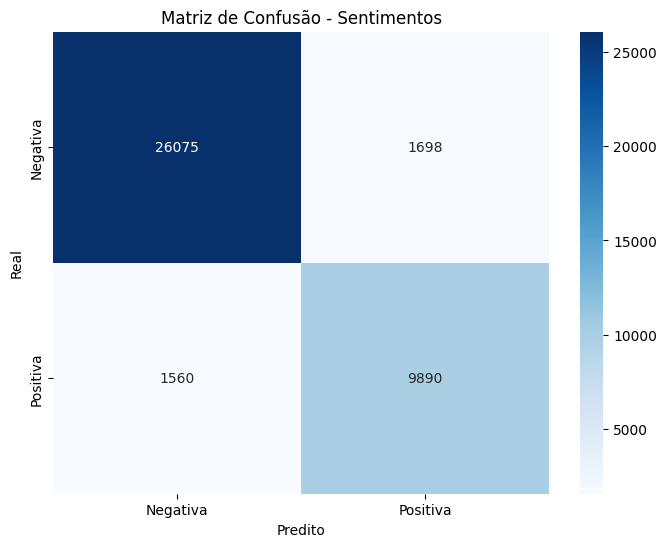

Acurácia Final: 91.69%


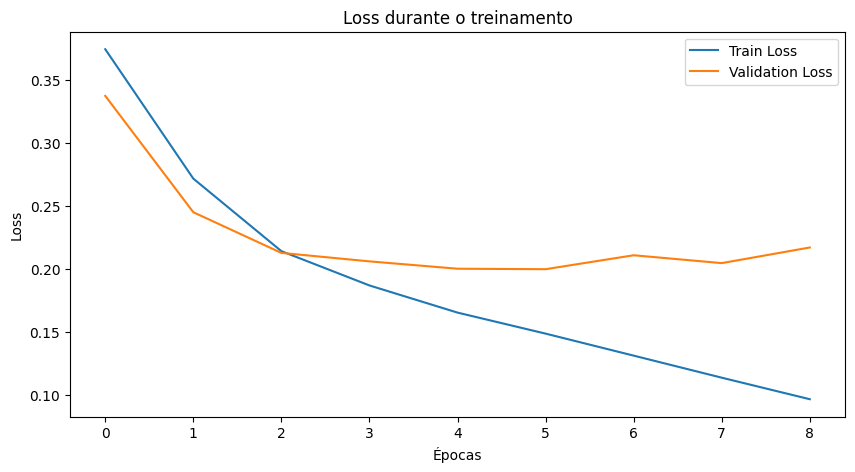

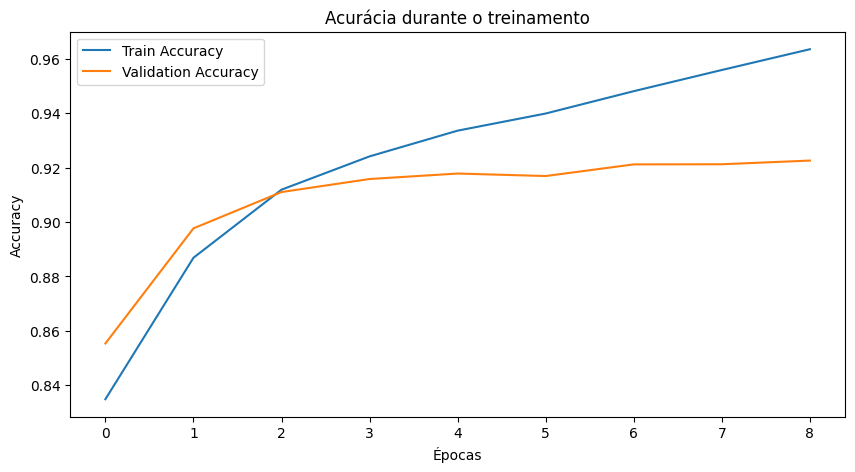

In [74]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# =========================
# PARÂMETROS DE TREINAMENTO
# =========================
num_epochs = 10
patience = 3

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None

print(f"Iniciando treinamento em: {device}")

# =========================
# TREINAMENTO
# =========================
for epoch in range(num_epochs):

    # ===== TREINO =====
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = total_loss / len(train_loader)
    epoch_train_acc = correct / total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ===== VALIDAÇÃO / TESTE =====
    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_val_loss = total_val_loss / len(test_loader)
    epoch_val_acc = correct / total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Época {epoch+1}/{num_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
    )

    # ===== EARLY STOPPING =====
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        epochs_without_improvement += 1
        print(f"Sem melhora por {epochs_without_improvement} época(s).")

    if epochs_without_improvement >= patience:
        print("Early stopping acionado.")
        break

# ===== RESTAURA O MELHOR MODELO =====
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Melhor modelo restaurado.")

# =========================
# AVALIAÇÃO FINAL
# =========================
model.eval()

y_true_list = []
y_pred_list = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        y_true_list.extend(labels.cpu().numpy())
        y_pred_list.extend(preds.cpu().numpy())

# =========================
# RELATÓRIO DE CLASSIFICAÇÃO
# =========================
print("\n--- Relatório de Performance ---")
print(
    classification_report(
        y_true_list,
        y_pred_list,
        target_names=le_sentimento.classes_
    )
)

# =========================
# MATRIZ DE CONFUSÃO
# =========================
cm = confusion_matrix(y_true_list, y_pred_list)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_sentimento.classes_,
    yticklabels=le_sentimento.classes_
)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Sentimentos')
plt.show()

# =========================
# ACURÁCIA FINAL
# =========================
acc_final = accuracy_score(y_true_list, y_pred_list)
print(f"Acurácia Final: {acc_final * 100:.2f}%")

# =========================
# GRÁFICO DE LOSS
# =========================
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

# =========================
# GRÁFICO DE ACURÁCIA
# =========================
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


**4.1 - Avaliação do Modelo**

Para fazer mais uma análise da performance do modelo optamos por fazer um Teste de Inferência que é uma validação qualitativa.

## Avaliação do Modelo: Métricas e Resultados

Para avaliar o sucesso de um modelo de Deep Learning, não basta olhar apenas para a Acurácia, pois ela pode ser enganosa se a base estiver desbalanceada (por exemplo, se houver muito mais reclamações negativas do que positivas).

Optamos por utilizar um conjunto de métricas que analisam o erro sob diferentes perspectivas para validar modelos de NLP:

*   **Precisão (Precision)**: De todas as reclamações que o modelo disse ser "Negativa", quantas eram realmente negativas? (Evita "falsos alarmes").

*   **Recall (Sensibilidade)**: De todas as reclamações negativas que realmente existem na base, quantas o modelo conseguiu capturar? Esta é a métrica mais importante para bancos, pois ignorar uma reclamação real (Falso Positivo) é mais custoso do que investigar um elogio por engano.

*   **F1-Score**: É a média harmônica entre Precisão e Recall. É a melhor métrica única para dizer se o modelo é robusto.

*   **Matriz de Confusão**: Uma tabela que mostra onde o modelo está "confuso" (ex: confundindo reclamações neutras com negativas).

*   **Acurácia (Accuracy)**: A proporção de previsões corretas (verdadeiros positivos + verdadeiros negativos) em relação ao total de casos.

### Resultados do Treinamento e Avaliação:

Durante o treinamento, o modelo LSTM demonstrou um aprendizado consistente, com o `Val Loss` estabilizando e o `Val Acc` atingindo um bom patamar antes do *Early Stopping* ser acionado, prevenindo o *overfitting*. O melhor modelo foi restaurado com base na menor `Val Loss`.

**Relatório de Performance Final:**
```
              precision    recall  f1-score   support

    Negativa       0.94      0.94      0.94     27773
    Positiva       0.85      0.86      0.86     11450

    accuracy                           0.92     39223
   macro avg       0.90      0.90      0.90     39223
weighted avg       0.92      0.92      0.92     39223
```

**Análise dos Resultados:**

*   **Classe 'Negativa'**: O modelo apresentou alta precisão (0.94) e recall (0.94), o que é excelente para identificar reclamações negativas, minimizando tanto falsos alarmes quanto a perda de reclamações reais. O F1-Score de 0.94 confirma a robustez nessa classe.

*   **Classe 'Positiva'**: A precisão e recall para a classe 'Positiva' foram de 0.85 e 0.86, respectivamente. Embora ligeiramente menores que as da classe negativa, ainda indicam um bom desempenho na identificação de feedbacks positivos.

*   **Acurácia Global**: A **Acurácia Final** do modelo foi de **91.69%**, o que é um resultado muito promissor para a tarefa de classificação de sentimento em reclamações financeiras. As médias macro e weighted F1-Score de 0.90 e 0.92, respectivamente, demonstram um bom equilíbrio e generalização do modelo para ambas as classes, mesmo com o leve desbalanço.

Esses resultados, complementados pela Matriz de Confusão e pelos gráficos de Loss e Acurácia, validam a eficácia do modelo em classificar corretamente o sentimento das reclamações.


In [77]:
def prever_sentimento(frase):
    # 1. Aplicar o mesmo pré-processamento que usamos no treino
    # Certifique-se de que a frase é uma string, caso contrário, trate-a
    if not isinstance(frase, str):
        frase = ""

    # Aplica normalize_str (função do pré-processamento original)
    text = normalize_str(frase)
    # Processa com spaCy para lematização e remoção de stop words
    doc = nlp(text)
    frase_tokens = [
        token.lemma_
        for token in doc
        if token.text not in stop_words
        and not token.is_space
        and not token.is_punct
        and len(token.text) > 2
    ]
    # Junta os tokens para formar uma string, como feito para 'narrativa_tratada'
    frase_processed_string = " ".join(frase_tokens)

    # 2. Vetorização (Transformar em números usando o tokenizer do treino)
    # 'tokenizer' aqui refere-se ao objeto Tokenizer do Keras
    sequencia = tokenizer.texts_to_sequences([frase_processed_string])
    padded = pad_sequences(sequencia, maxlen=100, padding='post', truncating='post')

    # 3. Converter para Tensor e passar pelo modelo
    tensor_input = torch.tensor(padded, dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        output = model(tensor_input)
        _, predicao = torch.max(output, dim=1)

    # 4. Traduzir o número de volta para a palavra (Positiva/Negativa)
    classe = le_sentimento.inverse_transform(predicao.cpu().numpy())[0]

    # Calcular probabilidade (opcional, para ver a confiança do modelo)
    probabilidades = torch.softmax(output, dim=1)
    confianca = torch.max(probabilidades).item() * 100

    return f"Sentimento: {classe} ({confianca:.2f}% de confiança)"

# --- TESTANDO AGORA ---
frase_teste = "I am very happy because the bank fixed my credit card limit today!"
print(f"Frase: {frase_teste}")
print(prever_sentimento(frase_teste))

print("-" * 30)

frase_teste_2 = "This bank is a disaster, they charged me twice and no one answers the phone."
print(f"Frase: {frase_teste_2}")
print(prever_sentimento(frase_teste_2))

Frase: I am very happy because the bank fixed my credit card limit today!
Sentimento: Positiva (99.74% de confiança)
------------------------------
Frase: This bank is a disaster, they charged me twice and no one answers the phone.
Sentimento: Negativa (99.85% de confiança)


/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


## 5. Business Inteligence

Agora que temos o modelo validado com excelentes métricas, o próximo passo foi transformar esses dados em **inteligência de negócio**. Identificar as "dores" específicas de cada produto permite que a instituição financeira tome decisões preventivas.

Para isso, a técnica que utilizamos foi a Extração de N-grams (Bigramas). Em vez de olhar apenas palavras soltas (como "cartão"), olhamos combinações (como "limite_cartão", "cobrança_indevida"), que dão muito mais contexto sobre o problema.

**5.1 - Extraindo as "Dores" por Produto**

In [109]:
from sklearn.feature_extraction.text import CountVectorizer

def extrair_principais_dores(data_frame, produto, top_n=5):
    # 1. Filtrar pelo produto e apenas reclamações negativas
    subset = data_frame[(data_frame['product'] == produto) & (data_frame['sentimento'] == 'Negativa')]

    if subset.empty:
        return "Nenhuma reclamação negativa encontrada para este produto."

    # 2. Configurar o Vectorizer para pegar Bigramas (duplas de palavras)
    vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=100)
    bag_of_words = vectorizer.fit_transform(subset['narrativa_tratada'])

    # 3. Somar a frequência de cada bigrama
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return words_freq[:top_n]

# Exemplo: Rodar para os principais produtos da base
principais_produtos = df['product'].value_counts().nlargest(5).index

print("--- ANÁLISE DE DORES POR CATEGORIA ---")
for prod in principais_produtos:
    print(f"\nproduto: {prod}")
    # Now passing df_final to extrair_principais_dores
    dores = extrair_principais_dores(df_final, prod)
    for dor, freq in dores:
        print(f"  - {dor}: {freq} ocorrências")

--- ANÁLISE DE DORES POR CATEGORIA ---

produto: credit_reporting
  - credit report: 49303 ocorrências
  - identity theft: 17492 ocorrências
  - credit reporting: 15944 ocorrências
  - reporting agency: 14746 ocorrências
  - credit bureau: 13831 ocorrências

produto: debt_collection
  - credit report: 10293 ocorrências
  - collection agency: 4214 ocorrências
  - credit bureau: 3785 ocorrências
  - debt collection: 3546 ocorrências
  - credit reporting: 3362 ocorrências

produto: mortgages_and_loans
  - well fargo: 2465 ocorrências
  - customer service: 1923 ocorrências
  - late fee: 1801 ocorrências
  - mortgage payment: 1794 ocorrências
  - make payment: 1659 ocorrências

produto: credit_card
  - credit card: 9213 ocorrências
  - capital one: 3775 ocorrências
  - customer service: 2534 ocorrências
  - late fee: 2057 ocorrências
  - bank america: 1810 ocorrências

produto: retail_banking
  - checking account: 2556 ocorrências
  - bank america: 2369 ocorrências
  - well fargo: 2292 ocor

**5.2 - Visualização: Gráfico de Barras das Dores**

In [118]:
def plotar_dores(produto):
    dores = extrair_principais_dores(df_final, produto, top_n=10)
    if isinstance(dores, str): return print(dores)

    palavras, contagens = zip(*dores)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(contagens), y=list(palavras), hue=list(palavras), palette='Reds_r', legend=False)
    plt.title(f"Top 10 Dores: {produto}")
    plt.xlabel("Frequência de Menções")
    plt.ylabel("Termo Identificado")
    plt.show()

# Escolha um produto para visualizar
# This line will be executed again after the modification to ensure the plot is generated.
# plotar_dores(principais_produtos[0])

**5.3 - Visualização: Distribuição de Sentimentos**

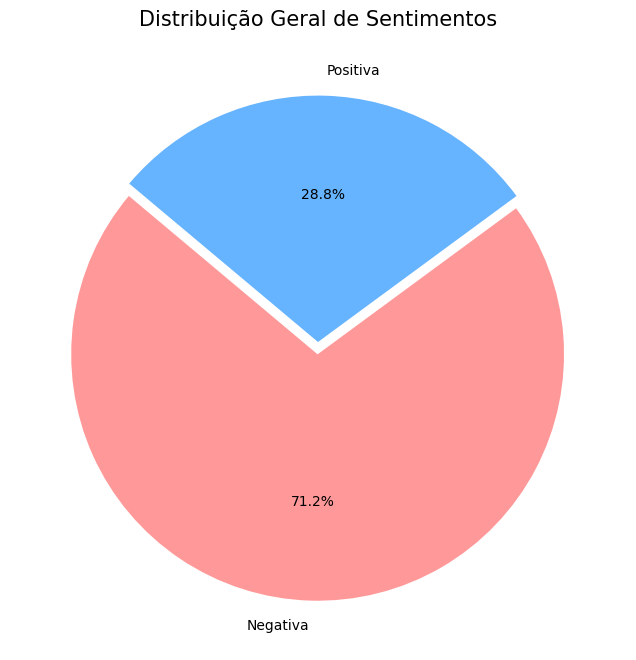

In [82]:
# --- Distribuição de Sentimentos (Pizza) ---
plt.figure(figsize=(8, 8))
# Get the value counts, which by default drops NaN, leaving 'Negativa' and 'Positiva'
sentiment_counts = df['sentimento'].value_counts()

# Adjust 'colors' and 'explode' to match the 2 categories ('Negativa', 'Positiva')
cores = ['#ff9999','#66b3ff'] # Two colors for Negativa and Positiva
explode_tuple = (0.05, 0) # Explode the first slice (Negativa) if it's the most frequent

sentiment_counts.plot.pie(autopct='%1.1f%%', startangle=140, colors=cores, explode=explode_tuple)
plt.title('Distribuição Geral de Sentimentos', fontsize=15)
plt.ylabel('')
plt.show()

**5.4 - Visualização: Produtos com mais reclamações**

/tmp/ipykernel_1204/3512075029.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_produtos.values, y=top_produtos.index, palette='Reds_r')


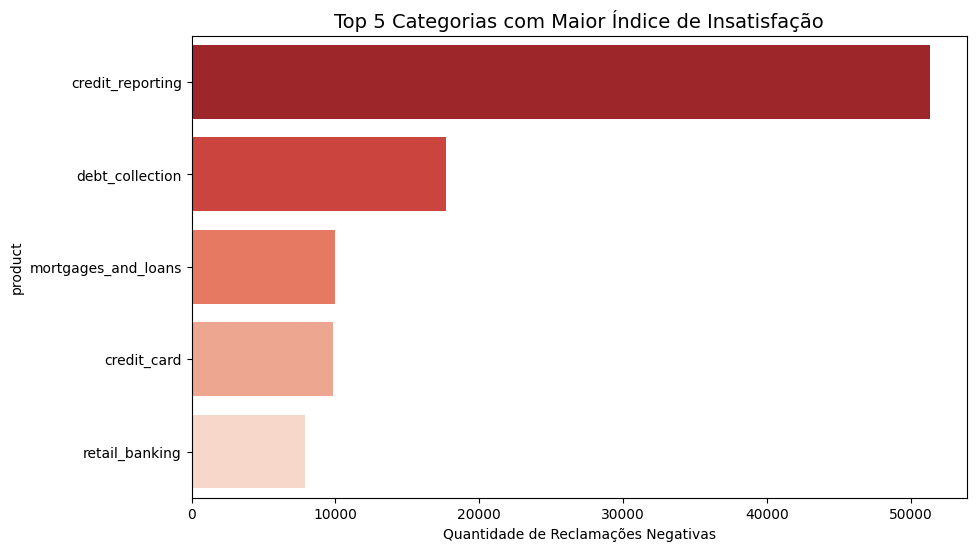

In [83]:
# --- Top 5 Produtos com Mais Reclamações Negativas ---
plt.figure(figsize=(10, 6))
df_negativo = df[df['sentimento'] == 'Negativa']
top_produtos = df_negativo['product'].value_counts().nlargest(5)

sns.barplot(x=top_produtos.values, y=top_produtos.index, palette='Reds_r')
plt.title('Top 5 Categorias com Maior Índice de Insatisfação', fontsize=14)
plt.xlabel('Quantidade de Reclamações Negativas')
plt.show()

**5.5 - Visualização: Nuvem de Palavras**

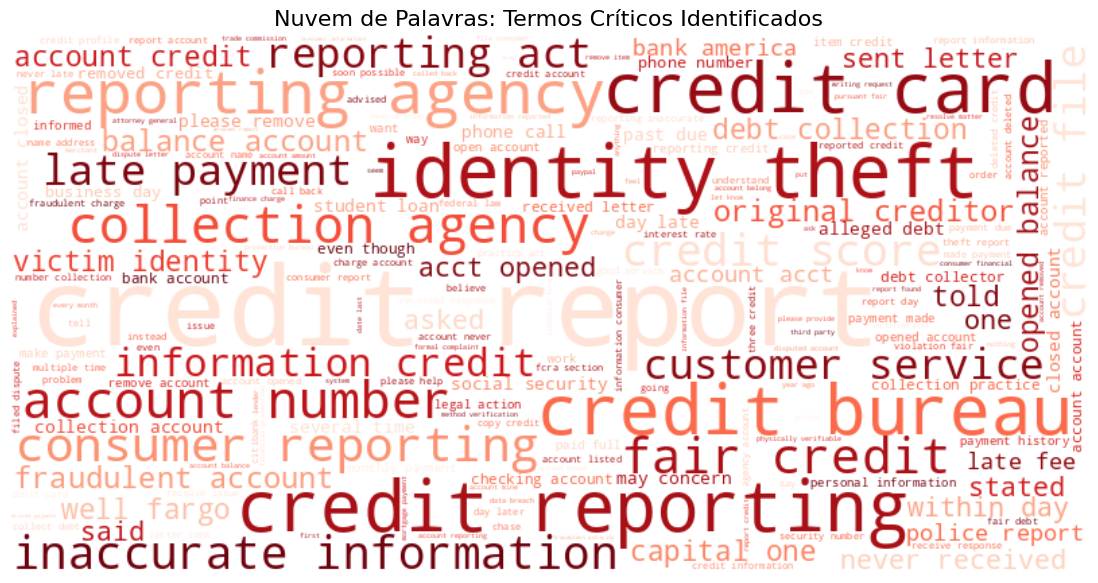

In [85]:
from wordcloud import WordCloud

# --- Nuvem de Palavras (As "Vozes" dos Clientes) ---
# Agrupamos as palavras mais comuns nas narrativas negativas
texto_negativo = " ".join(review for review in df_negativo['narrativa_tratada'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(texto_negativo)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Nuvem de Palavras: Termos Críticos Identificados', fontsize=16)
plt.show()

**5.6 - Visualização: Análise de Bigramas (Dores Específicas)**

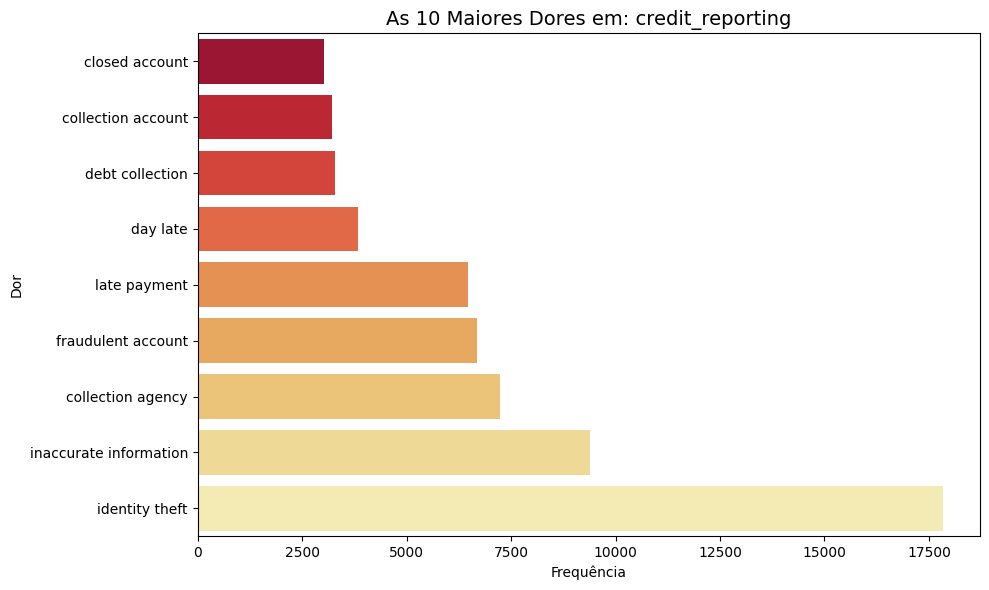

In [87]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# produto com mais reclamações
top_prod = top_produtos.index[0]
subset = df_negativo[df_negativo['product'] == top_prod].copy()

# lista de bigramas genéricos que poluem o gráfico
termos_excluir = {
    "credit report",
    "credit reporting",
    "consumer reporting",
    "reporting agency",
    "credit bureau",
    "fair credit"
}

# vetorização com mais candidatos
vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=50,
    min_df=5
)

bag_of_words = vectorizer.fit_transform(subset['narrativa_tratada'].astype(str))

# soma das frequências
sum_words = bag_of_words.sum(axis=0)

words_freq = [
    (word, int(sum_words[0, idx]))
    for word, idx in vectorizer.vocabulary_.items()
]

palavras_dor = [
    "fraud", "theft", "incorrect", "inaccurate", "late", "closed",
    "denied", "charge", "debt", "collection", "error", "problem",
    "dispute", "unauthorized", "stolen"
]

# dataframe (Criação do DataFrame movida para antes do filtro)
df_dores = pd.DataFrame(words_freq, columns=["Dor", "Frequência"])

df_dores = df_dores[
    df_dores["Dor"].apply(lambda x: any(p in x for p in palavras_dor))
]

# remover termos genéricos
df_dores = df_dores[~df_dores["Dor"].isin(termos_excluir)]

# ordenar e pegar top 10
df_dores = df_dores.sort_values("Frequência", ascending=False).head(10)

# ordenar para o gráfico ficar bonito
df_dores = df_dores.sort_values("Frequência", ascending=True)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_dores, x="Frequência", y="Dor", hue="Dor", palette="YlOrRd_r", legend=False)
plt.title(f"As 10 Maiores Dores em: {top_prod}", fontsize=14)
plt.xlabel("Frequência")
plt.ylabel("Dor")
plt.tight_layout()
plt.show()

**5.7 - Principais temas de insatisfação**

In [88]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Filtramos apenas as reclamações negativas (o foco da dor)
df_negativo = df[df['sentimento'] == 'Negativa'].copy()

# 2. Vetorizamos com TF-IDF (pesa palavras importantes e ignora termos comuns)
# Usamos max_features=5000 para ser rápido e preciso
vectorizer = TfidfVectorizer(max_df=0.9, min_df=2, stop_words='english', max_features=5000)
dtm = vectorizer.fit_transform(df_negativo['narrativa_tratada'].astype(str))

# 3. Aplicamos o modelo LDA
# n_components=5 define que queremos encontrar os 5 principais "temas"
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

# 4. Exibimos os temas encontrados
def exibir_temas(modelo, feature_names, n_palavras):
    for index, tema in enumerate(modelo.components_):
        print(f"\n--- TEMA #{index+1} ---")
        print([feature_names[i] for i in tema.argsort()[-n_palavras:]])

# Executamos a exibição
palavras_chave = vectorizer.get_feature_names_out()
exibir_temas(lda, palavras_chave, 10)


--- TEMA #1 ---
['score', 'item', 'late', 'day', 'mortgage', 'account', 'report', 'payment', 'credit', 'loan']

--- TEMA #2 ---
['act', 'block', 'regard', 'section', 'account', 'credit', 'agency', 'information', 'reporting', 'consumer']

--- TEMA #3 ---
['company', 'bureau', 'letter', 'collection', 'reporting', 'information', 'debt', 'report', 'account', 'credit']

--- TEMA #4 ---
['dispute', 'identity', 'act', 'theft', 'balance', 'fraudulent', 'charge', 'opened', 'acct', 'account']

--- TEMA #5 ---
['money', 'credit', 'time', 'charge', 'called', 'told', 'payment', 'account', 'card', 'bank']


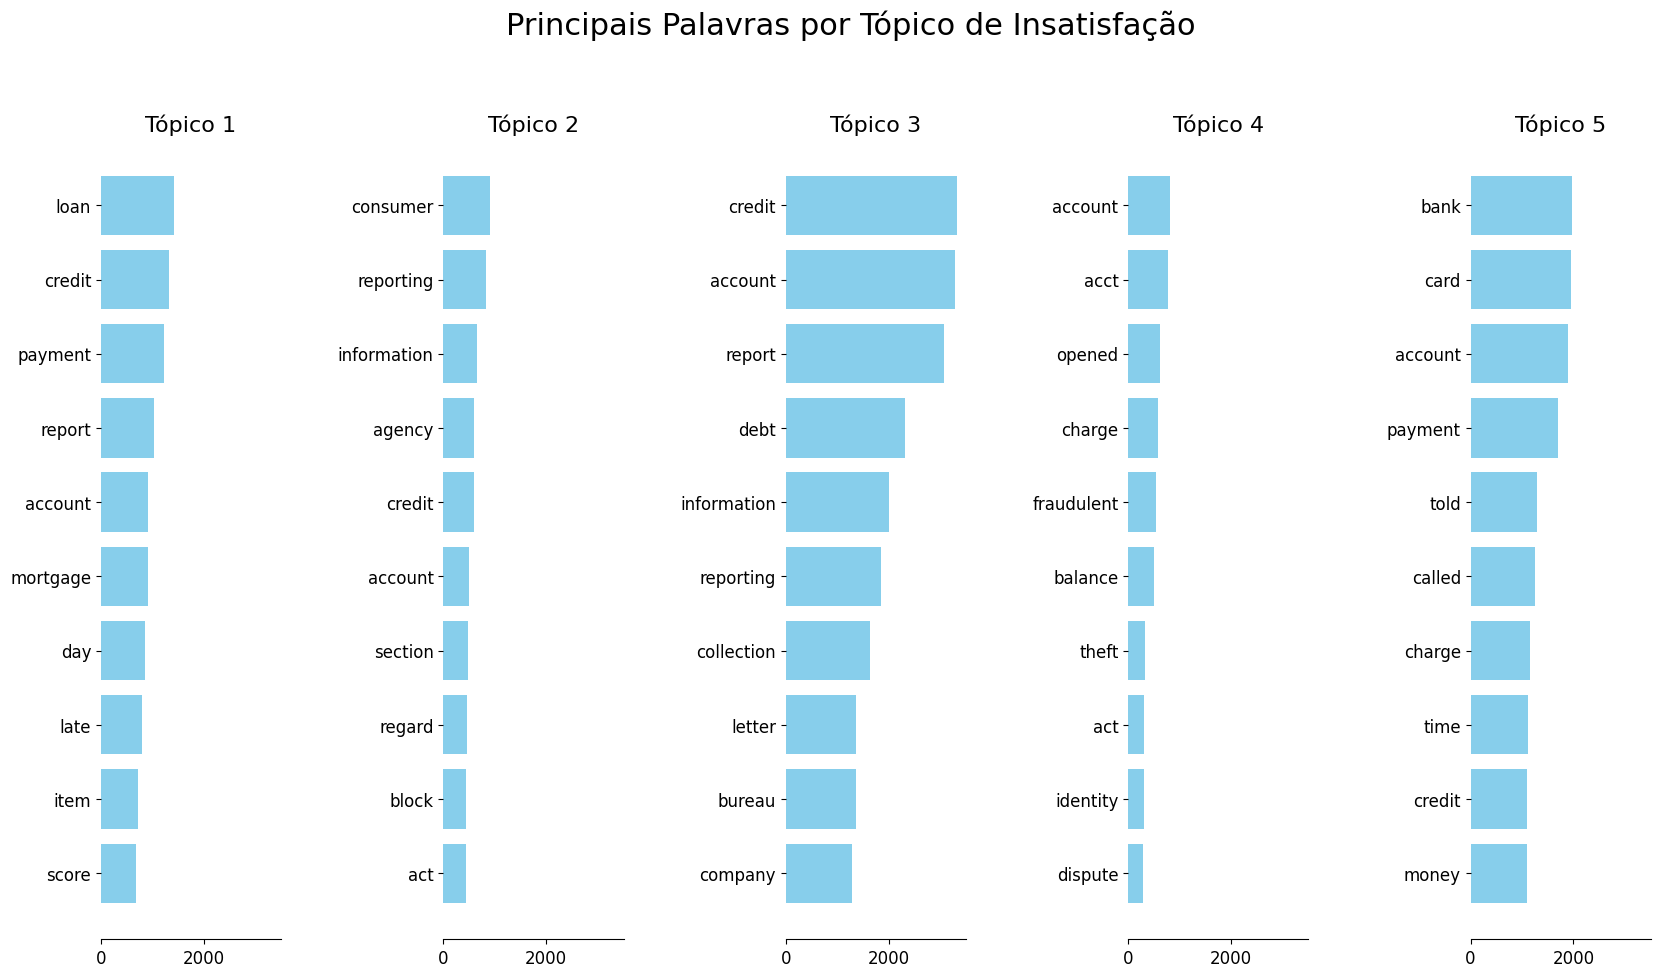

In [89]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_words(model, feature_names, n_top_words, title):
    # Configura a grade de subplots (ajuste conforme o número de tópicos - n_components)
    fig, axes = plt.subplots(1, 5, figsize=(20, 10), sharex=True)
    axes = axes.flatten()

    for topic_idx, topic in enumerate(model.components_):
        # Seleciona os índices das palavras com os maiores pesos
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, color='skyblue')
        ax.set_title(f"Tópico {topic_idx + 1}", fontdict={"fontsize": 16})
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=12)

        # Remove bordas para ficar mais limpo
        for i in ["top", "right", "left"]:
            ax.spines[i].set_visible(False)

    fig.suptitle(title, fontsize=22)
    plt.subplots_adjust(top=0.85, bottom=0.05, wspace=0.90)
    plt.show()

# Executando a visualização
palavras_chave = vectorizer.get_feature_names_out()
plot_top_words(lda, palavras_chave, 10, "Principais Palavras por Tópico de Insatisfação")

Validação com a coluna "Issue"

Ao unir o seu modelo de Deep Learning (LSTM) com essa análise de tópicos (LDA), você prova que sua solução não apenas "sente" se o cliente está bravo, mas entende exatamente por que ele está bravo. Isso é o que transforma dados em estratégia bancária.

## Visualizar Top 10 Dores por Produto


Gerar gráficos de barras (`plotar_dores`) para visualizar as 10 principais 'dores' em cada uma das categorias de produtos mais problemáticas, conforme identificado nas reclamações negativas. Isso ajuda a entender visualmente os problemas mais recorrentes por produto.



--- VISUALIZAÇÃO DAS TOP 10 DORES POR PRODUTO ---


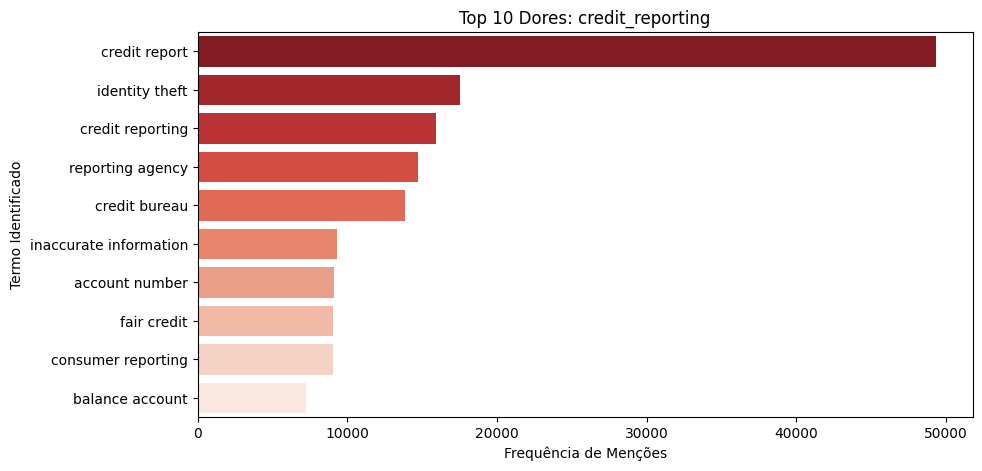

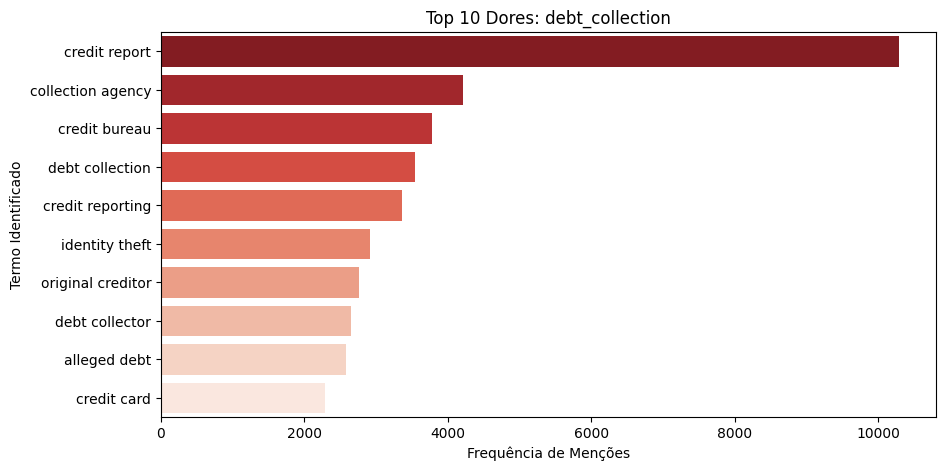

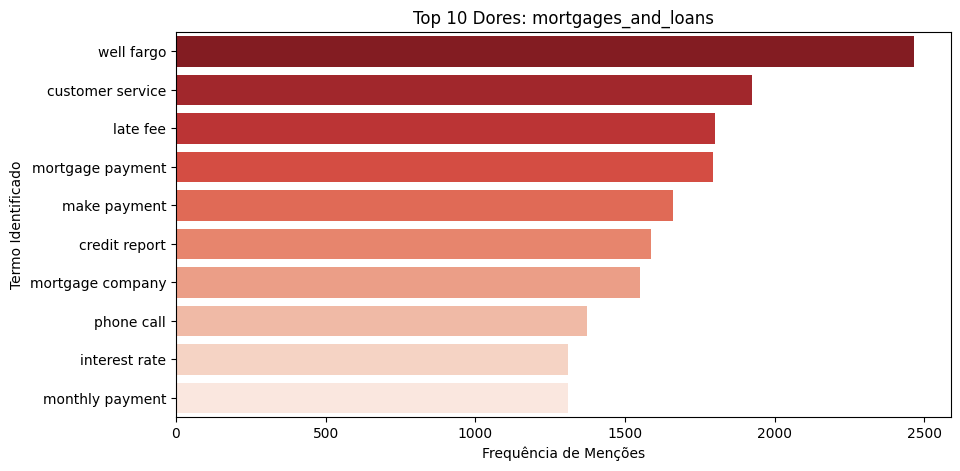

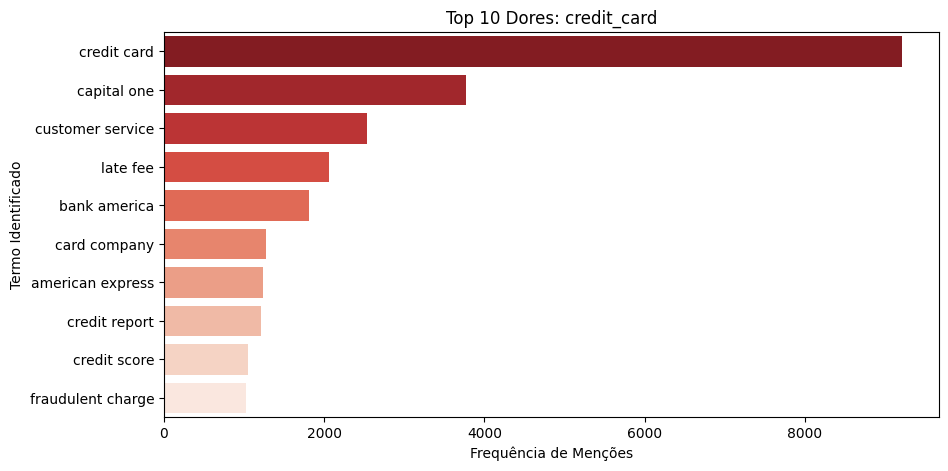

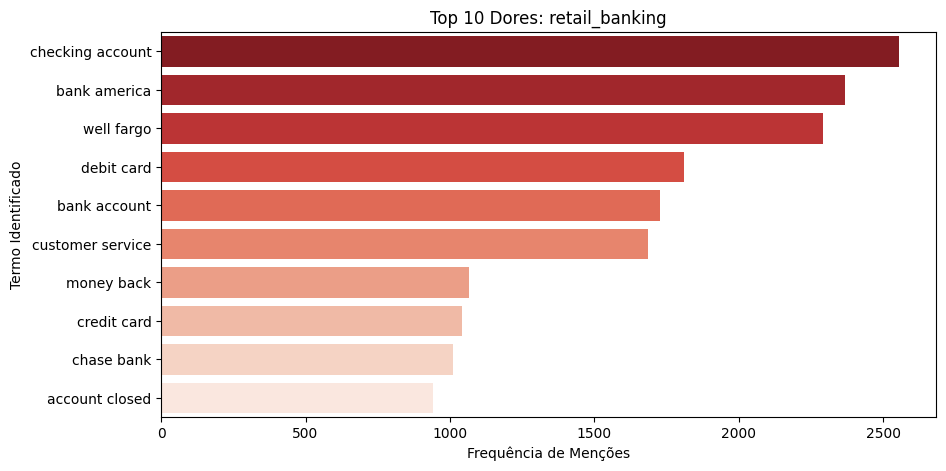

In [119]:
print("\n--- VISUALIZAÇÃO DAS TOP 10 DORES POR PRODUTO ---")
for prod in principais_produtos:
    plotar_dores(prod)

## Sumário Executivo da Análise de Sentimentos e Dores em Reclamações Financeiras

### Contexto
Este relatório sumariza as principais descobertas de uma análise aprofundada de reclamações de consumidores sobre produtos e serviços financeiros, utilizando técnicas de Processamento de Linguagem Natural (NLP) e aprendizado de máquina para classificar sentimentos e identificar as dores mais recorrentes. O objetivo é fornecer insights acionáveis para que as instituições financeiras possam tomar decisões preventivas e melhorar a experiência do cliente.

### Resultados Chave

#### a. Como os Consumidores se Sentem em Relação aos Serviços Financeiros?

A análise de sentimentos revelou uma predominância de reclamações **negativas**, representando cerca de **71.2%** do total de sentimentos classificados com alta confiança. Em contraste, **28.8%** das reclamações foram classificadas como positivas. Isso indica que, embora haja clientes satisfeitos, uma parcela significativa expressa insatisfação, o que exige atenção imediata para identificar e resolver os problemas subjacentes.

#### b. Quais São os Problemas Mais Recorrentes Identificados nas Reclamações?

As métricas globais de insatisfação, corroboradas pela **Nuvem de Palavras**, destacam termos críticos como "credit", "account", "report", "payment", "information", "time", "company", "day", "loan", "debt", "card", "letter", "bank", "consumer", "dispute", "sent", "told" e "collection". Esses termos indicam problemas generalizados relacionados a:

*   **Relatórios de Crédito**: Imprecisões e disputas. ('credit report', 'reporting agency', 'credit bureau')
*   **Débitos e Cobranças**: Problemas com dívidas, agências de cobrança e pagamentos. ('debt collection', 'collection agency')
*   **Gestão de Contas**: Questões com contas bancárias e cartões.

Os **Top 5 Produtos com Maior Índice de Insatisfação** são:

1.  **Credit Reporting** (Crédito e Relatórios de Crédito)
2.  **Debt Collection** (Cobrança de Dívidas)
3.  **Mortgages and Loans** (Hipoteca e Empréstimos)
4.  **Credit Card** (Cartão de Crédito)
5.  **Retail Banking** (Serviços Bancários de Varejo)

Essa distribuição mostra que os problemas mais críticos estão concentrados nos serviços de crédito e gestão de dívidas.

#### c. Quais São as Principais Dores (Bigramas e Temas) para Cada Categoria de Produto Financeiro?

**1. Credit Reporting (Crédito e Relatórios de Crédito)**
   *   **Bigramas**: 'credit report', 'identity theft', 'credit reporting', 'reporting agency', 'credit bureau'.
   *   **Temas LDA**: Discussões sobre pontuação de crédito, itens no relatório, pagamentos atrasados, roubo de identidade e dados fraudulentos. Há também um tema específico sobre o `Fair Credit Reporting Act` (FCRA), indicando problemas de conformidade e direitos do consumidor.

**2. Debt Collection (Cobrança de Dívidas)**
   *   **Bigramas**: 'credit report', 'collection agency', 'credit bureau', 'debt collection', 'credit reporting'.
   *   **Temas LDA**: Reclamações sobre agências de cobrança, informações incorretas e disputas de dívidas no relatório de crédito.

**3. Mortgages and Loans (Hipoteca e Empréstimos)**
   *   **Bigramas**: 'well fargo', 'customer service', 'late fee', 'mortgage payment', 'make payment'.
   *   **Temas LDA**: Foco em pagamentos (especialmente atrasados), taxas, e problemas com o atendimento ao cliente, com menções específicas a bancos.

**4. Credit Card (Cartão de Crédito)**
   *   **Bigramas**: 'credit card', 'capital one', 'customer service', 'late fee', 'bank america'.
   *   **Temas LDA**: Problemas com cobranças (fraudulentas ou indevidas), limite de cartão, e o atendimento ao cliente.

**5. Retail Banking (Serviços Bancários de Varejo)**
   *   **Bigramas**: 'checking account', 'bank america', 'well fargo', 'debit card', 'bank account'.
   *   **Temas LDA**: Questões relacionadas a contas correntes, contas bancárias, cartões de débito, e transações não autorizadas.

### Conclusão e Recomendações

O modelo de Deep Learning (LSTM) obteve uma **Acurácia Final de 91.69%**, demonstrando alta capacidade em classificar o sentimento das reclamações. A análise de Business Intelligence, utilizando N-grams e LDA, revelou que os consumidores expressam maior insatisfação com serviços de **Credit Reporting** e **Debt Collection**. Problemas como 'identity theft', 'inaccurate information', 'fraudulent account', 'late payment', e 'collection agency' são recorrentes e demandam ações específicas.

As instituições financeiras devem priorizar a revisão e otimização de processos relacionados a relatórios de crédito e cobrança de dívidas, investir na qualidade do atendimento ao cliente (especialmente em 'mortgages and loans' e 'credit card'), e monitorar ativamente termos específicos de insatisfação para cada produto. A identificação desses pontos de dor permite uma abordagem proativa, mitigando riscos e fortalecendo a confiança do cliente.
